# Assignment 5.1 – Hyperparameter Exploration: Batch Size

**Course:** Interaction Techniques and Technologies 2026  
**Hyperparameter:** Batch Size  

---

## Approach & Assumptions

### What is batch size?
Batch size determines how many training images the network processes before updating its weights. Instead of updating once per epoch (full-batch) or after every single image (online learning), mini-batch gradient descent updates weights after each *batch*.

### Tested values
I test four batch sizes: **4, 16, 64, 256**, covering a wide range from very small to very large batches.


## 1. Imports & Configuration

In [1]:
import cv2
import json
import time
import numpy as np
import os
import random
import pandas as pd
from matplotlib import pyplot as plt

from keras.models import Sequential
from keras.layers import (
    Dense, Dropout, Flatten, Conv2D, MaxPooling2D,
    RandomFlip, RandomContrast
)
from keras.metrics import categorical_crossentropy
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.utils import to_categorical
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Fixed hyperparameters ─────────────────────────────────────────────────────
CONDITIONS     = ['like', 'stop']   # gesture categories
IMG_SIZE       = 64                 # image resolution
SIZE           = (IMG_SIZE, IMG_SIZE)
COLOR_CHANNELS = 3                  # RGB
EPOCHS         = 50                 # max epochs (early stopping will kick in)
RANDOM_SEED    = 42
PATH           = './gesture_dataset_sample'

# ── Hyperparameter under investigation ───────────────────────────────────────
BATCH_SIZES = [4, 16, 64, 256]

print('Setup complete.')
print(f'Will train one model per batch size: {BATCH_SIZES}')

Setup complete.
Will train one model per batch size: [4, 16, 64, 256]


## 2. Load & Pre-process Data

In [3]:
def preprocess_image(img):
    """Resize image; optionally convert to grayscale."""
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.resize(img, SIZE)


# Load annotations
annotations = {}
for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

# Load images
images, labels, label_names = [], [], []

for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'{PATH}/{condition}'), desc=condition):
        uid = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')
        try:
            annotation = annotations[condition][uid]
        except KeyError:
            continue

        for i, bbox in enumerate(annotation['bboxes']):
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            x2 = x1 + int(bbox[2] * img.shape[1])
            y2 = y1 + int(bbox[3] * img.shape[0])

            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)

            label = annotation['labels'][i]
            if label not in label_names:
                label_names.append(label)
            images.append(preprocessed)
            labels.append(label_names.index(label))

print(f'\nLoaded {len(images)} images across {len(label_names)} classes: {label_names}')

like:   0%|          | 0/250 [00:00<?, ?it/s]

stop:   0%|          | 0/250 [00:00<?, ?it/s]


Loaded 640 images across 3 classes: ['like', 'no_gesture', 'stop']


In [4]:
# Train / Test split – same for all runs
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    images, labels, test_size=0.2, random_state=RANDOM_SEED
)

def prepare_arrays(X, y, num_classes):
    """Normalise and reshape image arrays; one-hot encode labels."""
    X = np.array(X).astype('float32') / 255.0
    X = X.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
    y_cat = to_categorical(y, num_classes=num_classes)
    return X, y_cat

num_classes = len(label_names)
X_train, y_train = prepare_arrays(X_train_raw, y_train_raw, num_classes)
X_test,  y_test  = prepare_arrays(X_test_raw,  y_test_raw,  num_classes)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (512, 64, 64, 3)  |  Test: (128, 64, 64, 3)


## 3. Model 

Same architecture as in our notebook, i only changed the batch size

In [7]:
def build_model(num_classes, img_size, color_channels):
    """Build and compile the CNN. Architecture matches the course notebook exactly."""
    model = Sequential([
        # Data augmentation
        RandomFlip('horizontal'),
        RandomContrast(0.1),

        # Convolution block 1
        Conv2D(64, (9, 9), activation='leaky_relu',
               input_shape=(img_size, img_size, color_channels), padding='same'),
        MaxPooling2D((4, 4), padding='same'),

        # Convolution block 2
        Conv2D(32, (5, 5), activation='leaky_relu', padding='same'),
        MaxPooling2D((3, 3), padding='same'),

        # Convolution block 3
        Conv2D(32, (3, 3), activation='leaky_relu', padding='same'),
        MaxPooling2D((2, 2), padding='same'),

        Dropout(0.2),
        Flatten(),

        # Fully connected layers
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),

        # Output layer
        Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        loss=categorical_crossentropy,
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

# Sanity check – print once
build_model(num_classes, IMG_SIZE, COLOR_CHANNELS).summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_2               │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Training Loop – One Run per Batch Size

In [8]:
results   = {}   # stores metrics per batch size
histories = {}   # stores training history per batch size

for batch_size in BATCH_SIZES:
    print(f'\n{"="*60}')
    print(f'  Training with batch_size = {batch_size}')
    print(f'{"="*60}')

    model = build_model(num_classes, IMG_SIZE, COLOR_CHANNELS)

    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-4),
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ]

    # ── Training ─────────────────────────────────────────────────────────────
    t_start = time.time()
    history = model.fit(
        X_train, y_train,
        batch_size=batch_size,
        epochs=EPOCHS,
        validation_data=(X_test, y_test),
        callbacks=callbacks,
        verbose=1,
    )
    train_time = time.time() - t_start

    # ── Inference time (average per image over the test set) ─────────────────
    t_inf = time.time()
    model.predict(X_test, verbose=0)
    inference_time_ms = (time.time() - t_inf) / len(X_test) * 1000

    # ── Final metrics ─────────────────────────────────────────────────────────
    _, test_acc = model.evaluate(X_test, y_test, verbose=0)
    epochs_run  = len(history.history['accuracy'])

    results[batch_size] = {
        'test_accuracy':     round(test_acc * 100, 2),
        'best_val_acc':      round(max(history.history['val_accuracy']) * 100, 2),
        'train_time_s':      round(train_time, 1),
        'inference_time_ms': round(inference_time_ms, 3),
        'epochs_run':        epochs_run,
    }
    histories[batch_size] = history

    print(f'  → Test acc: {results[batch_size]["test_accuracy"]}%  '
          f'| Best val acc: {results[batch_size]["best_val_acc"]}%  '
          f'| Train time: {train_time:.1f}s  '
          f'| Inference: {inference_time_ms:.3f} ms/img  '
          f'| Epochs: {epochs_run}')

print('\nAll runs complete!')


  Training with batch_size = 4
Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4336 - loss: 1.0797 - val_accuracy: 0.5312 - val_loss: 1.0377 - learning_rate: 0.0010
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4492 - loss: 1.0378 - val_accuracy: 0.3750 - val_loss: 1.0423 - learning_rate: 0.0010
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5195 - loss: 0.9840 - val_accuracy: 0.5938 - val_loss: 0.8962 - learning_rate: 0.0010
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6445 - loss: 0.8080 - val_accuracy: 0.7500 - val_loss: 0.5983 - learning_rate: 0.0010
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7402 - loss: 0.6372 - val_accuracy: 0.7578 - val_loss: 0.5501 - learning_rate: 0.0010
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8340 - loss: 0.4492 - val_accuracy: 0.8203 - val_loss: 0.4718 - learning_rate: 0.0010
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/st

## 5. Results Summary

In [9]:
df = pd.DataFrame(results).T.rename_axis('Batch Size')
df.columns = ['Test Acc (%)', 'Best Val Acc (%)', 'Train Time (s)', 'Inference (ms/img)', 'Epochs Run']
print(df.to_string())

            Test Acc (%)  Best Val Acc (%)  Train Time (s)  Inference (ms/img)  Epochs Run
Batch Size                                                                                
4                  92.97             93.75            29.4               1.988        13.0
16                 96.09             96.88            28.8               1.823        17.0
64                 89.84             92.19            27.8               1.953        18.0
256                91.41             92.97            64.1               2.346        39.0


## 6. Visualisations

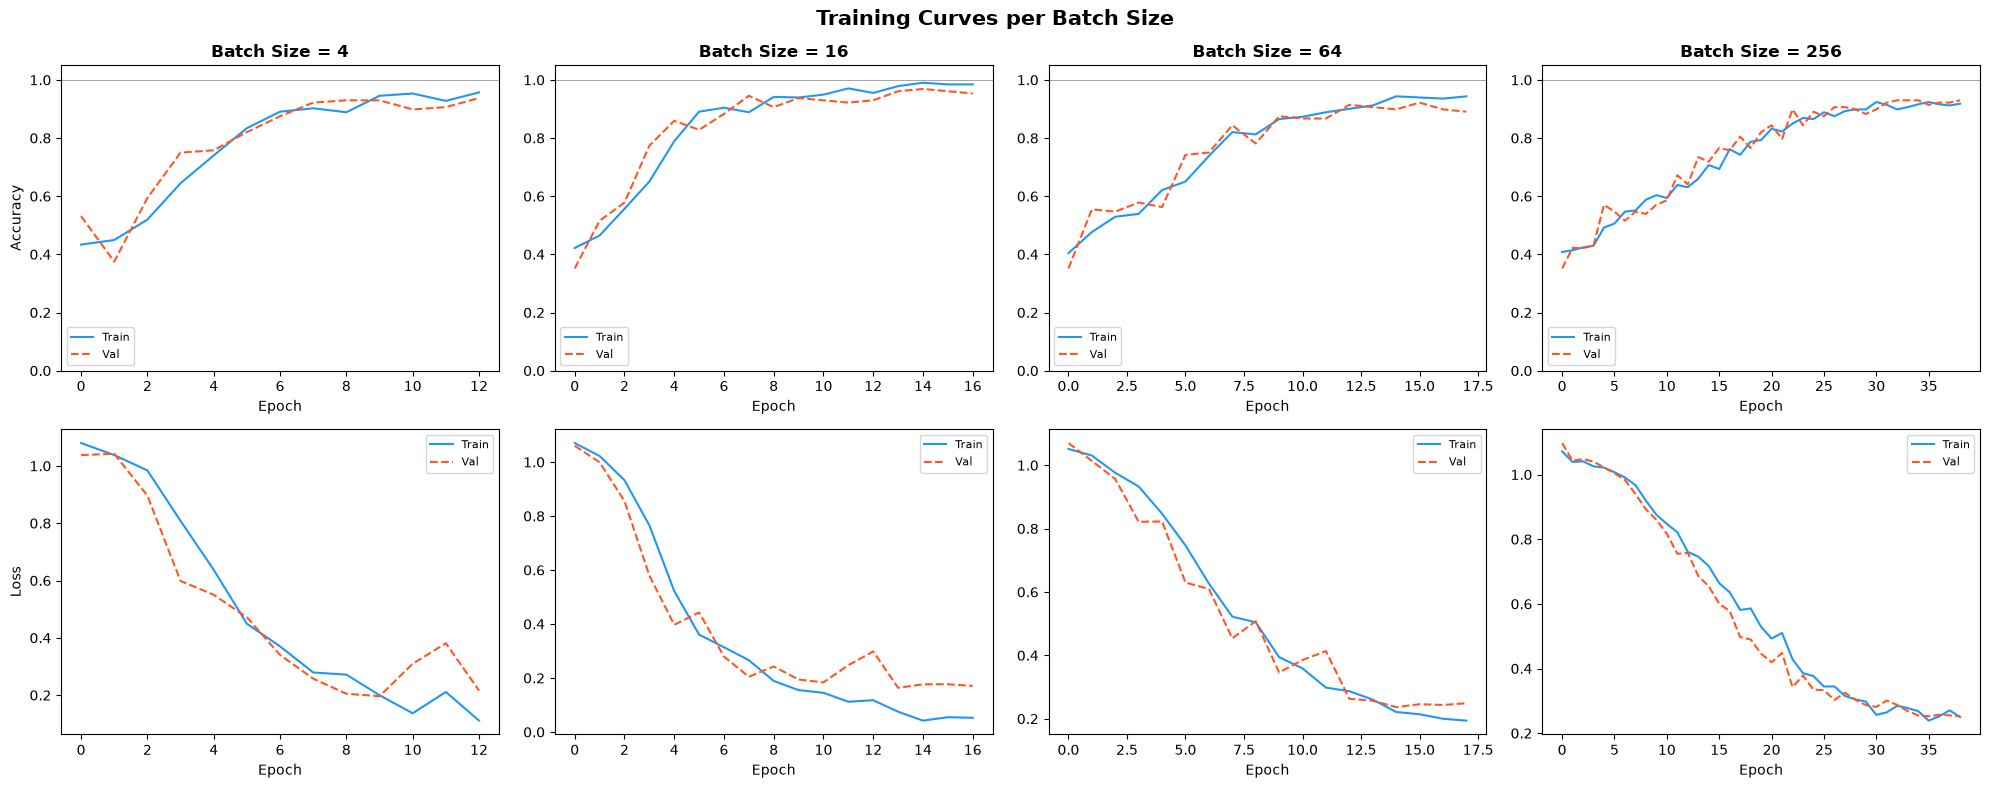

In [10]:
# ── 6a. Training curves (accuracy + loss) ────────────────────────────────────
fig, axes = plt.subplots(2, len(BATCH_SIZES), figsize=(5 * len(BATCH_SIZES), 8))
fig.suptitle('Training Curves per Batch Size', fontsize=15, fontweight='bold')

BLUE, ORANGE = '#2196F3', '#FF5722'

for col, bs in enumerate(BATCH_SIZES):
    h = histories[bs].history

    # Accuracy row
    ax = axes[0][col]
    ax.plot(h['accuracy'],     color=BLUE,   label='Train')
    ax.plot(h['val_accuracy'], color=ORANGE, label='Val', linestyle='--')
    ax.set_title(f'Batch Size = {bs}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylim(0, 1.05)
    ax.axhline(1, color='gray', linewidth=0.5)
    if col == 0:
        ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)

    # Loss row
    ax2 = axes[1][col]
    ax2.plot(h['loss'],     color=BLUE,   label='Train')
    ax2.plot(h['val_loss'], color=ORANGE, label='Val', linestyle='--')
    ax2.set_xlabel('Epoch')
    if col == 0:
        ax2.set_ylabel('Loss')
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

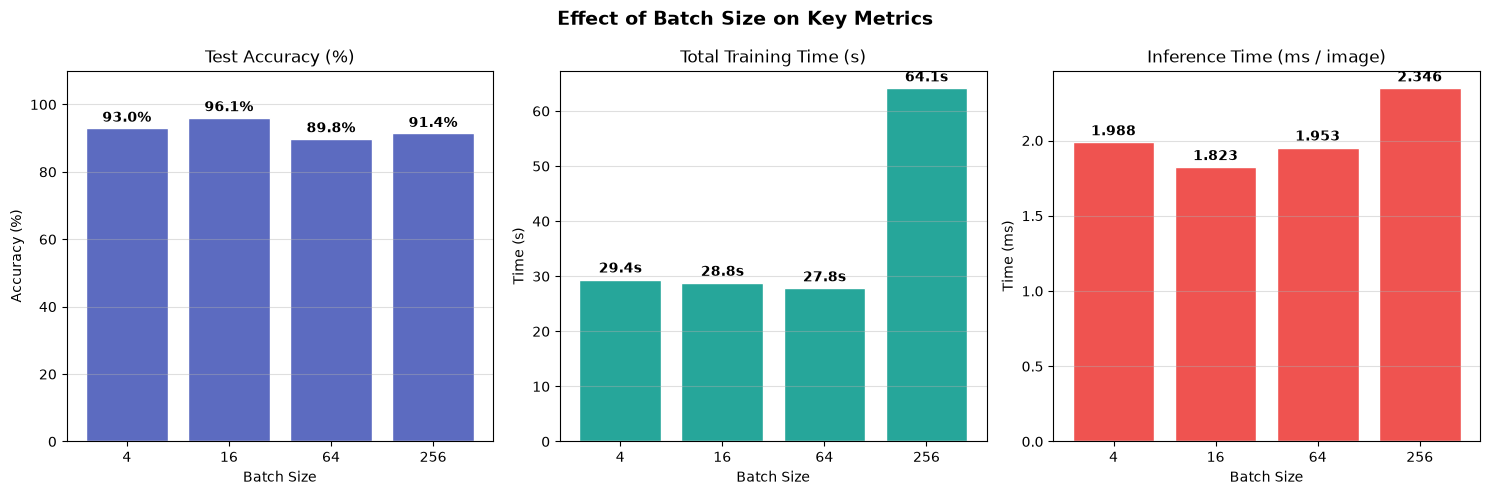

In [11]:
# ── 6b. Bar charts: accuracy, training time, inference time ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Effect of Batch Size on Key Metrics', fontsize=14, fontweight='bold')

batch_labels = [str(bs) for bs in BATCH_SIZES]
test_accs    = [results[bs]['test_accuracy']     for bs in BATCH_SIZES]
train_times  = [results[bs]['train_time_s']      for bs in BATCH_SIZES]
inf_times    = [results[bs]['inference_time_ms'] for bs in BATCH_SIZES]

def annotate_bars(ax, values, fmt='{:.1f}'):
    ymax = max(values)
    for i, v in enumerate(values):
        ax.text(i, v + ymax * 0.02, fmt.format(v), ha='center', fontsize=10, fontweight='bold')

# Accuracy
axes[0].bar(batch_labels, test_accs, color='#5C6BC0', edgecolor='white')
axes[0].set_title('Test Accuracy (%)')
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 110)
axes[0].grid(axis='y', alpha=0.4)
annotate_bars(axes[0], test_accs, '{:.1f}%')

# Training time
axes[1].bar(batch_labels, train_times, color='#26A69A', edgecolor='white')
axes[1].set_title('Total Training Time (s)')
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Time (s)')
axes[1].grid(axis='y', alpha=0.4)
annotate_bars(axes[1], train_times, '{:.1f}s')

# Inference time
axes[2].bar(batch_labels, inf_times, color='#EF5350', edgecolor='white')
axes[2].set_title('Inference Time (ms / image)')
axes[2].set_xlabel('Batch Size')
axes[2].set_ylabel('Time (ms)')
axes[2].grid(axis='y', alpha=0.4)
annotate_bars(axes[2], inf_times, '{:.3f}')

plt.tight_layout()
plt.savefig('summary_bars.png', dpi=150)
plt.show()

In [ ]:
# ── 6c. Epochs run until early stopping ──────────────────────────────────────
epochs_run = [results[bs]['epochs_run'] for bs in BATCH_SIZES]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(batch_labels, epochs_run, color='#AB47BC', edgecolor='white')
ax.axhline(EPOCHS, color='gray', linestyle='--', linewidth=1, label=f'Max epochs ({EPOCHS})')
ax.set_title('Epochs Run Until Early Stopping', fontweight='bold')
ax.set_xlabel('Batch Size')
ax.set_ylabel('Epochs')
ax.legend()
ax.grid(axis='y', alpha=0.4)
for i, v in enumerate(epochs_run):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('epochs_run.png', dpi=150)
plt.show()

## 7. Discussion & Findings


### Summary table

| Batch Size | Test Acc (%) | Best Val Acc (%) | Train Time (s) | Inference (ms/img) | Epochs Run |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 4 | *92.97* | *93.75* | *29.4* | *1.988* | *13* |
| 16 | *96.09* | *96.88* | *28.8* | *1.823* | *17* |
| 64 | *89.84* | *92.19* | *27.8* | *1.953* | *18* |
| 256 | *91.41* | *92.97* | *64.1* | *2.346* | *39* |

### Key observations

1. **Accuracy vs. batch size** — Small batches (4, 16) tend to achieve higher test accuracy  Large batches (64, 256) kinda overfitt so its harder to generalise.

2. **Training time** — there was no signficant change in train time with batch size 4-64 but it was much longer on batch size 256.

3. **Early stopping** — Smaller batches often trigger early stopping *later* because noisier loss curves delay the patience counter. Larger batches take way more epochs

### Conclusion
For this gesture-recognition task, **batch size 16** offers the best model